# SSLPA — Full-Graph 5-Fold Stratified CV: Evaluation Plots

Results from running SSLPA on the full LCC transaction graph with stratified 5-fold cross-validation.  
- **Extrinsic metrics** (NMI, ARI, Purity) measure label agreement on the held-out test nodes.
- **Intrinsic metrics** (Modularity, Coverage, Conductance) measure structural quality of the discovered communities.
- **Clustering stats** describe the size distribution of communities and the fraction of unlabeled nodes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
})

folds_df   = pd.read_csv('sslpa_fold_results.csv')
summary_df = pd.read_csv('sslpa_cv_summary.csv')

FOLDS  = folds_df['fold'].values
FOLD_LABELS = [f'Fold {i}' for i in FOLDS]
COLORS = ['#2166ac', '#d6604d', '#4dac26', '#762a83', '#f4a582']

print(folds_df[['fold','nmi','ari','purity','modularity','coverage','conductance']].to_string(index=False))

 fold      nmi      ari   purity  modularity  coverage  conductance
    1 0.178675 0.144042 0.960878    0.340038  0.959542     0.690089
    2 0.295988 0.308181 0.962786    0.547876  0.925031     0.685522
    3 0.273698 0.288455 0.962309    0.372604  0.932074     0.705357
    4 0.249999 0.281443 0.961355    0.091757  0.951262     0.709801
    5 0.233981 0.260277 0.960401    0.460171  0.932262     0.736301


## 1. Extrinsic Metrics per Fold (NMI, ARI, Purity)

Scores computed on the **held-out test nodes** only. Each bar = one fold value. The mean bar with ±1 std error bar is shown on the right of each subplot.

In [ ]:
ext_metrics = [
    ('nmi',    'NMI',    '#2166ac'),
    ('ari',    'ARI',    '#d6604d'),
    ('purity', 'Purity', '#4dac26'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)

for ax, (col, label, color) in zip(axes, ext_metrics):
    vals = folds_df[col].values
    mean = vals.mean()
    std  = vals.std(ddof=1)

    # individual fold bars (no error bar — each is a single observation)
    fold_bars = ax.bar(FOLDS, vals, color=color, edgecolor='black',
                       linewidth=0.7, alpha=0.75, width=0.55)

    # mean bar with ±std error bar, placed after the last fold
    mean_x = len(FOLDS) + 1
    ax.bar(mean_x, mean, yerr=std, color=color, edgecolor='black',
           linewidth=0.9, alpha=1.0, width=0.55,
           capsize=6, error_kw=dict(elinewidth=1.8, ecolor='black'))

    # value labels on fold bars
    for bar, val in zip(fold_bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

    # value label on mean bar
    ax.text(mean_x, mean + std + 0.015, f'{mean:.3f}\n±{std:.3f}',
            ha='center', va='bottom', fontsize=8.5, linespacing=1.4)

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.set_xticks(list(FOLDS) + [mean_x])
    ax.set_xticklabels([f'Fold {f}' for f in FOLDS] + ['Mean'], rotation=15, ha='right')
    ax.set_ylim(0, min(1.08, mean + std + 0.12))
    ax.axvline(len(FOLDS) + 0.5, color='gray', linewidth=1, linestyle=':', alpha=0.6)
    ax.grid(axis='y', alpha=0.35, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('SSLPA — Extrinsic Test Metrics per Fold + Mean ±Std (Stratified 5-Fold CV)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('plot_extrinsic_per_fold.pdf', bbox_inches='tight')
plt.show()

## 2. Intrinsic Metrics per Fold (Modularity, Coverage, Conductance)

Structural quality of the full graph partition produced by SSLPA in each fold.  
- **Modularity**: fraction of intra-community edges vs. random baseline (higher = better).
- **Coverage**: fraction of all edges that are intra-community (higher = better).
- **Conductance**: average boundary ratio per community (lower = better).

Each bar = one fold value. The mean bar with ±1 std error bar is shown on the right.

In [ ]:
int_metrics = [
    ('modularity',   'Modularity',  '#762a83', 'higher is better'),
    ('coverage',     'Coverage',    '#1b7837', 'higher is better'),
    ('conductance',  'Conductance', '#b35806', 'lower is better'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, (col, label, color, note) in zip(axes, int_metrics):
    vals = folds_df[col].values
    mean = vals.mean()
    std  = vals.std(ddof=1)

    # individual fold bars
    fold_bars = ax.bar(FOLDS, vals, color=color, edgecolor='black',
                       linewidth=0.7, alpha=0.75, width=0.55)

    # mean bar with ±std error bar
    mean_x = len(FOLDS) + 1
    ax.bar(mean_x, mean, yerr=std, color=color, edgecolor='black',
           linewidth=0.9, alpha=1.0, width=0.55,
           capsize=6, error_kw=dict(elinewidth=1.8, ecolor='black'))

    # value labels on fold bars
    for bar, val in zip(fold_bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

    # value label on mean bar
    ax.text(mean_x, mean + std + 0.01, f'{mean:.3f}\n±{std:.3f}',
            ha='center', va='bottom', fontsize=8.5, linespacing=1.4)

    ax.set_title(f'{label}\n({note})', fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.set_xticks(list(FOLDS) + [mean_x])
    ax.set_xticklabels([f'Fold {f}' for f in FOLDS] + ['Mean'], rotation=15, ha='right')
    spread = vals.max() - vals.min()
    pad = max(spread * 0.2, 0.04)
    ax.set_ylim(max(0, vals.min() - pad), min(1.05, mean + std + pad + 0.08))
    ax.axvline(len(FOLDS) + 0.5, color='gray', linewidth=1, linestyle=':', alpha=0.6)
    ax.grid(axis='y', alpha=0.35, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('SSLPA — Intrinsic Graph Metrics per Fold + Mean ±Std (Stratified 5-Fold CV)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('plot_intrinsic_per_fold.pdf', bbox_inches='tight')
plt.show()

## 3. All Six Metrics — Summary Bar Chart (Mean ± Std)

Single-panel overview of all metrics for easy comparison in a report or presentation.

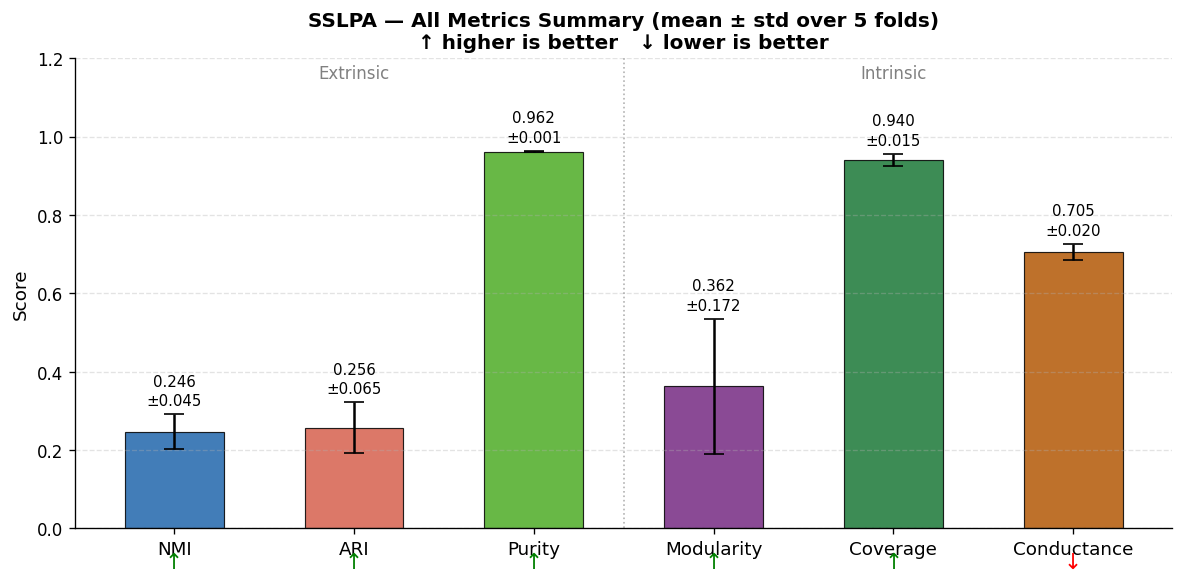

In [4]:
all_metrics = [
    ('nmi',         'NMI',          '#2166ac'),
    ('ari',         'ARI',          '#d6604d'),
    ('purity',      'Purity',       '#4dac26'),
    ('modularity',  'Modularity',   '#762a83'),
    ('coverage',    'Coverage',     '#1b7837'),
    ('conductance', 'Conductance',  '#b35806'),
]

means = [folds_df[c].mean() for c, _, _ in all_metrics]
stds  = [folds_df[c].std(ddof=1) for c, _, _ in all_metrics]
labels = [lbl for _, lbl, _ in all_metrics]
colors = [col for _, _, col in all_metrics]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(all_metrics))

bars = ax.bar(x, means, yerr=stds, color=colors, edgecolor='black',
              linewidth=0.7, capsize=6, alpha=0.85, width=0.55)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.015,
            f'{mean:.3f}\n±{std:.3f}',
            ha='center', va='bottom', fontsize=9, linespacing=1.4)

# annotate the direction of "good" for each metric
directions = ['↑', '↑', '↑', '↑', '↑', '↓']
for i, (d, bar) in enumerate(zip(directions, bars)):
    ax.text(bar.get_x() + bar.get_width() / 2, -0.06,
            d, ha='center', va='top', fontsize=13,
            color='green' if d == '↑' else 'red')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.2)
ax.axvline(2.5, color='gray', linewidth=1, linestyle=':', alpha=0.6)
ax.text(1.0, 1.15, 'Extrinsic', ha='center', fontsize=10, color='gray')
ax.text(4.0, 1.15, 'Intrinsic', ha='center', fontsize=10, color='gray')
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('SSLPA — All Metrics Summary (mean ± std over 5 folds)\n↑ higher is better   ↓ lower is better',
             fontweight='bold')
fig.tight_layout()
plt.savefig('plot_all_metrics_summary.pdf', bbox_inches='tight')
plt.show()

## 4. Community Count and Singleton Communities per Fold

Singletons are communities with only one node — they contribute to modularity and coverage calculations but carry no structural information.

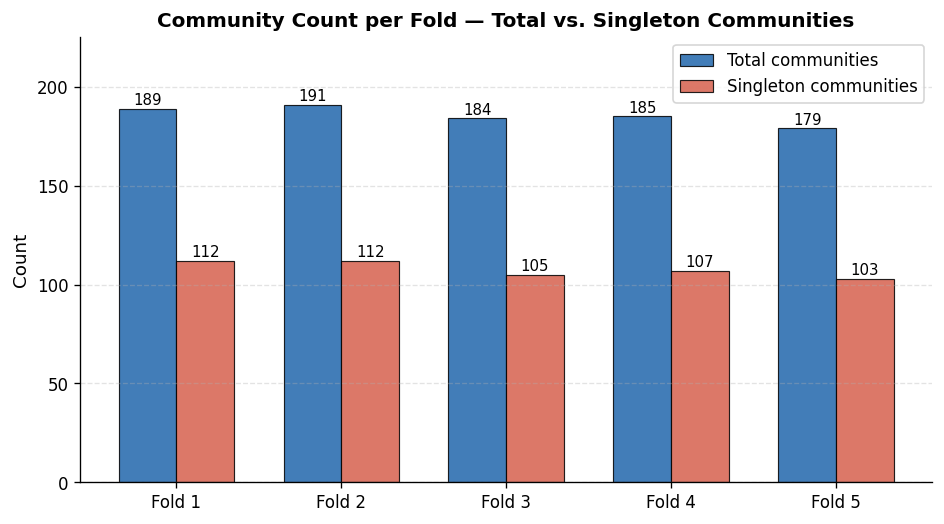

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bw = 0.35
x = np.arange(len(FOLDS))

b1 = ax.bar(x - bw/2, folds_df['n_communities'], bw,
            label='Total communities', color='#2166ac',
            edgecolor='black', linewidth=0.7, alpha=0.85)
b2 = ax.bar(x + bw/2, folds_df['n_singletons'], bw,
            label='Singleton communities', color='#d6604d',
            edgecolor='black', linewidth=0.7, alpha=0.85)

for bar, val in zip(b1, folds_df['n_communities']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=9)
for bar, val in zip(b2, folds_df['n_singletons']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(FOLD_LABELS)
ax.set_ylabel('Count')
ax.set_title('Community Count per Fold — Total vs. Singleton Communities',
             fontweight='bold')
ax.legend(frameon=True)
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, folds_df['n_communities'].max() * 1.18)

fig.tight_layout()
plt.savefig('plot_community_counts.pdf', bbox_inches='tight')
plt.show()

## 5. Community Size Statistics per Fold

Mean and max community size. The large max values reflect a dominant hub community (highly skewed distribution, typical for real-world networks).

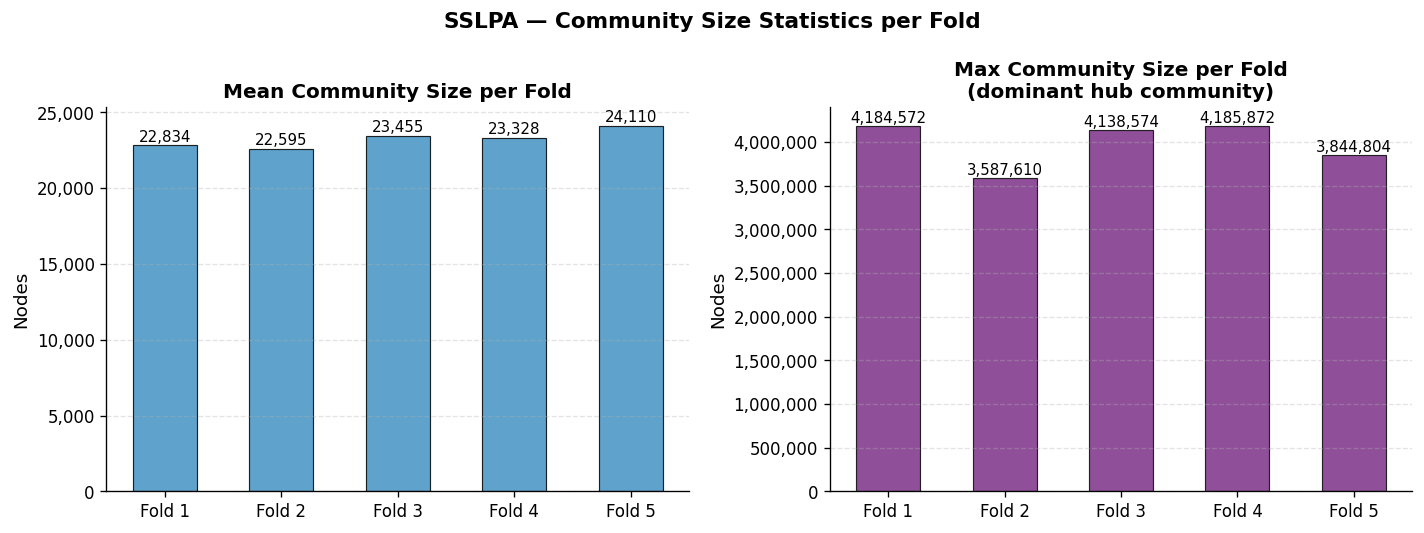

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Mean community size ──
ax = axes[0]
ax.bar(FOLDS, folds_df['mean_size'], color='#4393c3',
       edgecolor='black', linewidth=0.7, alpha=0.85, width=0.55)
for fold, val in zip(FOLDS, folds_df['mean_size']):
    ax.text(fold, val + 50, f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(FOLDS)
ax.set_xticklabels(FOLD_LABELS)
ax.set_ylabel('Nodes')
ax.set_title('Mean Community Size per Fold', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Max community size ──
ax = axes[1]
ax.bar(FOLDS, folds_df['max_size'], color='#762a83',
       edgecolor='black', linewidth=0.7, alpha=0.82, width=0.55)
for fold, val in zip(FOLDS, folds_df['max_size']):
    ax.text(fold, val + 5000, f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(FOLDS)
ax.set_xticklabels(FOLD_LABELS)
ax.set_ylabel('Nodes')
ax.set_title('Max Community Size per Fold\n(dominant hub community)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('SSLPA — Community Size Statistics per Fold',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('plot_community_sizes.pdf', bbox_inches='tight')
plt.show()

## 6. Fraction of Unlabeled Nodes per Fold

SSLPA propagates labels from seed nodes; nodes that remain unreachable stay unlabeled.  
A near-zero unlabeled fraction indicates that the graph is well-connected and seeds cover it effectively.

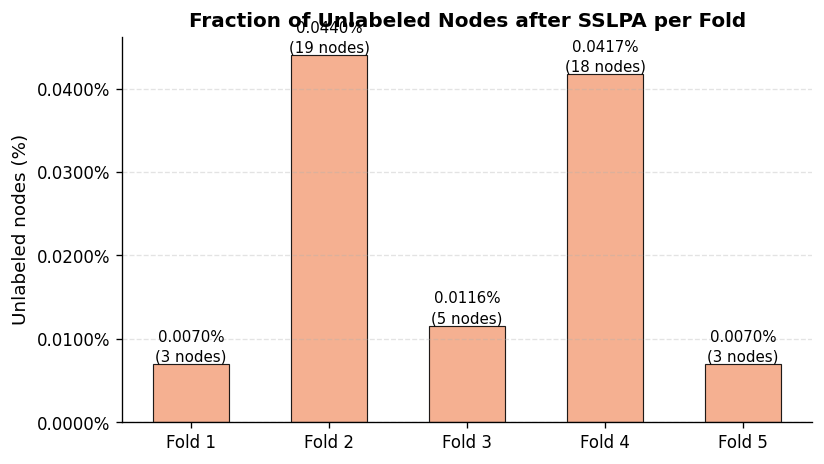

Max unlabeled: 0.04403% — propagation covers virtually all nodes.


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

unlabeled_pct = folds_df['pct_unlabeled'].values * 100  # already in %, scale for display
# pct_unlabeled in CSV is a fraction (e.g. 6.9e-5), convert to %
unlabeled_pct = folds_df['pct_unlabeled'].values * 100

bars = ax.bar(FOLDS, unlabeled_pct, color='#f4a582',
              edgecolor='black', linewidth=0.7, alpha=0.88, width=0.55)

for bar, val, n in zip(bars, unlabeled_pct, folds_df['n_unlabeled']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.000002,
            f'{val:.4f}%\n({int(n)} nodes)',
            ha='center', va='bottom', fontsize=9, linespacing=1.4)

ax.set_xticks(FOLDS)
ax.set_xticklabels(FOLD_LABELS)
ax.set_ylabel('Unlabeled nodes (%)')
ax.set_title('Fraction of Unlabeled Nodes after SSLPA per Fold',
             fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.4f}%'))
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.savefig('plot_unlabeled.pdf', bbox_inches='tight')
plt.show()
print(f"Max unlabeled: {unlabeled_pct.max():.5f}% — propagation covers virtually all nodes.")

## 7. Extrinsic vs. Intrinsic Metrics — Scatter Plot

Each point is one fold. Reveals whether folds with better structural quality (higher modularity) also yield better label agreement (higher NMI).

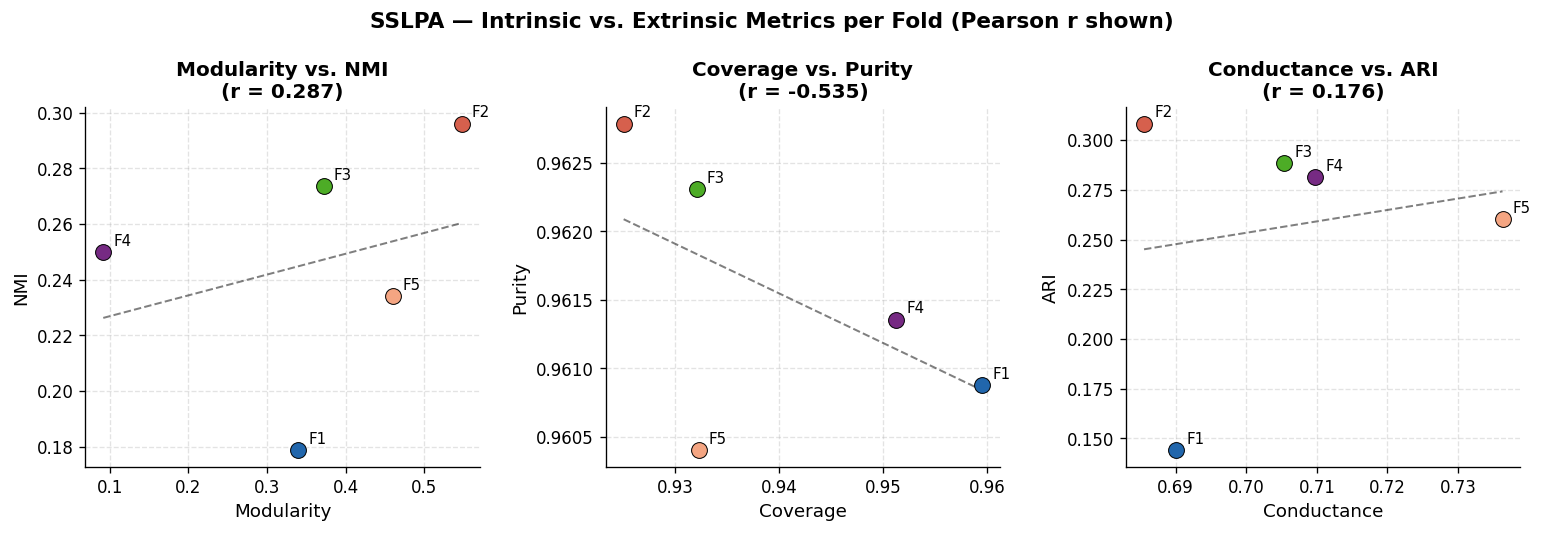

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

pairs = [
    ('modularity', 'nmi',    'Modularity', 'NMI'),
    ('coverage',   'purity', 'Coverage',   'Purity'),
    ('conductance','ari',    'Conductance','ARI'),
]

for ax, (xc, yc, xlabel, ylabel) in zip(axes, pairs):
    xs = folds_df[xc].values
    ys = folds_df[yc].values

    for i, (x, y, f) in enumerate(zip(xs, ys, FOLDS)):
        ax.scatter(x, y, color=COLORS[i], s=90, zorder=3,
                   edgecolors='black', linewidths=0.6)
        ax.annotate(f'F{f}', (x, y), textcoords='offset points',
                    xytext=(6, 4), fontsize=9)

    # Pearson correlation
    r = np.corrcoef(xs, ys)[0, 1]
    # trend line
    m, b = np.polyfit(xs, ys, 1)
    xfit = np.linspace(xs.min(), xs.max(), 100)
    ax.plot(xfit, m * xfit + b, 'k--', linewidth=1.2, alpha=0.5)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{xlabel} vs. {ylabel}\n(r = {r:.3f})', fontweight='bold')
    ax.grid(alpha=0.35, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('SSLPA — Intrinsic vs. Extrinsic Metrics per Fold (Pearson r shown)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('plot_intrinsic_vs_extrinsic.pdf', bbox_inches='tight')
plt.show()

## 8. Summary Table

Mean ± std over all 5 folds for every reported metric.

In [9]:
report_cols = [
    ('nmi',          'NMI'),
    ('ari',          'ARI'),
    ('purity',       'Purity'),
    ('modularity',   'Modularity'),
    ('coverage',     'Coverage'),
    ('conductance',  'Conductance'),
    ('n_communities','# Communities'),
    ('n_singletons', '# Singletons'),
    ('pct_unlabeled','% Unlabeled'),
    ('iterations',   'Iterations'),
    ('sslpa_time',   'Runtime (s)'),
]

rows = []
for col, name in report_cols:
    vals = folds_df[col].values
    rows.append({
        'Metric': name,
        'Fold 1': vals[0],
        'Fold 2': vals[1],
        'Fold 3': vals[2],
        'Fold 4': vals[3],
        'Fold 5': vals[4],
        'Mean':   vals.mean(),
        'Std':    vals.std(ddof=1),
    })

tbl = pd.DataFrame(rows)

fmt_cols = ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5','Mean','Std']
for c in fmt_cols:
    tbl[c] = tbl[c].map(lambda v: f'{v:.4f}')

print(tbl.to_string(index=False))

       Metric   Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Mean    Std
          NMI   0.1787   0.2960   0.2737   0.2500   0.2340   0.2465 0.0446
          ARI   0.1440   0.3082   0.2885   0.2814   0.2603   0.2565 0.0651
       Purity   0.9609   0.9628   0.9623   0.9614   0.9604   0.9615 0.0010
   Modularity   0.3400   0.5479   0.3726   0.0918   0.4602   0.3625 0.1716
     Coverage   0.9595   0.9250   0.9321   0.9513   0.9323   0.9400 0.0146
  Conductance   0.6901   0.6855   0.7054   0.7098   0.7363   0.7054 0.0200
# Communities 189.0000 191.0000 184.0000 185.0000 179.0000 185.6000 4.6690
 # Singletons 112.0000 112.0000 105.0000 107.0000 103.0000 107.8000 4.0866
  % Unlabeled   0.0001   0.0004   0.0001   0.0004   0.0001   0.0002 0.0002
   Iterations   4.0000   4.0000   4.0000   4.0000   4.0000   4.0000 0.0000
  Runtime (s)  73.1002  67.9364  67.5939  68.6353  67.5395  68.9611 2.3547
